# DSA210 Term Project — Full Analysis Notebook
## Identifying High-Potential but Under-Engaged Customers
### Through Education, Income, Campaign Behavior, and Macroeconomic Context
---
Pipeline: 1) Preprocessing → 2) EDA → 3) Hypothesis Tests → 4) ML Models


In [1]:
import warnings; warnings.filterwarnings('ignore')
import os, sys, zipfile

PROJECT_DIR = os.getcwd()
raw_dir = os.path.join(PROJECT_DIR, 'data', 'raw')
for arc, csv in [('archive.zip','marketing_campaign.csv'), ('archive (1).zip','US_inflation_rates.csv')]:
    if not os.path.exists(os.path.join(raw_dir, csv)):
        with zipfile.ZipFile(os.path.join(raw_dir, arc)) as z:
            z.extract(csv, raw_dir)
print('Environment ready.')


Environment ready.


---
## Step 1: Data Preprocessing & Feature Engineering

In [1]:
"""
DSA210 - Data Preprocessing
Loads raw data, merges CPI, engineers features, saves cleaned dataset.
"""

import pandas as pd
import numpy as np
import os

# ── Paths ────────────────────────────────────────────────────────────────────
RAW_DIR  = os.path.join(os.path.dirname(__file__), "data", "raw")
PROC_DIR = os.path.join(os.path.dirname(__file__), "data", "processed")
os.makedirs(PROC_DIR, exist_ok=True)

# ── 1. Load raw data ──────────────────────────────────────────────────────────
print("Loading raw data...")
df  = pd.read_csv(os.path.join(RAW_DIR, "marketing_campaign.csv"), sep="\t")
cpi = pd.read_csv(os.path.join(RAW_DIR, "US_inflation_rates.csv"))

print(f"  Customers  : {len(df):,} rows, {len(df.columns)} columns")
print(f"  CPI records: {len(cpi):,} rows")

# ── 2. Parse dates ────────────────────────────────────────────────────────────
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)
cpi["date"]       = pd.to_datetime(cpi["date"])

# Create a month-level key for CPI merge
df["enroll_month"] = df["Dt_Customer"].dt.to_period("M")
cpi["enroll_month"] = cpi["date"].dt.to_period("M")
cpi = cpi.rename(columns={"value": "CPI_at_enrollment"})

# ── 3. Merge CPI ──────────────────────────────────────────────────────────────
df = df.merge(
    cpi[["enroll_month", "CPI_at_enrollment"]],
    on="enroll_month",
    how="left"
)
print(f"  CPI merge nulls: {df['CPI_at_enrollment'].isna().sum()}")

# ── 4. Handle missing values ──────────────────────────────────────────────────
# Income: fill 24 missing with median within education group
df["Income"] = df.groupby("Education")["Income"].transform(
    lambda x: x.fillna(x.median())
)
print(f"  Missing Income after fill: {df['Income'].isna().sum()}")

# ── 5. Feature engineering ────────────────────────────────────────────────────
# Age
df["Age"] = 2024 - df["Year_Birth"]

# Total spend across all product categories
spend_cols = ["MntWines", "MntFruits", "MntMeatProducts",
              "MntFishProducts", "MntSweetProducts", "MntGoldProds"]
df["TotalSpend"] = df[spend_cols].sum(axis=1)

# Campaign Engagement Score (0–6)
campaign_cols = ["AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3",
                 "AcceptedCmp4", "AcceptedCmp5", "Response"]
df["CampaignScore"] = df[campaign_cols].sum(axis=1)
df["CampaignEngaged"] = (df["CampaignScore"] > 0).astype(int)  # binary flag

# RFM metrics
#   Recency  : already in dataset (days since last purchase)
#   Frequency: total number of purchases across all channels
purchase_cols = ["NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases"]
df["Frequency"] = df[purchase_cols].sum(axis=1)
#   Monetary : TotalSpend (already computed)

# Has children flag
df["HasChild"] = ((df["Kidhome"] + df["Teenhome"]) > 0).astype(int)

# Education tier (ordinal)
edu_order = {"Basic": 0, "2n Cycle": 1, "Graduation": 2, "Master": 3, "PhD": 4}
df["EduTier"] = df["Education"].map(edu_order)

# Relative income: customer income vs median income of same education group
df["EduMedianIncome"] = df.groupby("Education")["Income"].transform("median")
df["RelativeIncome"]  = df["Income"] / df["EduMedianIncome"]

# High-potential definition:
#   TotalSpend >= 75th percentile within education group
#   AND CampaignScore == 0  (never responded to any campaign)
spend_q75 = df.groupby("Education")["TotalSpend"].transform(
    lambda x: x.quantile(0.75)
)
df["HighPotential"]    = (df["TotalSpend"] >= spend_q75).astype(int)
df["UnderEngaged"]     = (df["CampaignScore"] == 0).astype(int)
df["TargetSegment"]    = ((df["HighPotential"] == 1) & (df["UnderEngaged"] == 1)).astype(int)

# ── 6. Clean up anomalous values ─────────────────────────────────────────────
# Remove clearly wrong birth years (age > 100)
before = len(df)
df = df[df["Age"] <= 100].copy()
print(f"  Removed {before - len(df)} rows with Age > 100")

# ── 7. Save processed dataset ─────────────────────────────────────────────────
out_path = os.path.join(PROC_DIR, "customers_processed.csv")
df.drop(columns=["enroll_month"]).to_csv(out_path, index=False)
print(f"\nSaved processed data → {out_path}")
print(f"Final shape: {df.shape}")
print(f"\nTarget segment (high-potential & under-engaged): {df['TargetSegment'].sum()} customers")
print(df[["Education", "TargetSegment"]].groupby("Education")["TargetSegment"].sum().sort_values(ascending=False))


Loading raw data...
  Customers  : 2,240 rows, 29 columns
  CPI records: 918 rows
  CPI merge nulls: 0
  Missing Income after fill: 0
  Removed 3 rows with Age > 100

Saved processed data → data/processed/customers_processed.csv
Final shape: (2237, 43)

Target segment (high-potential & under-engaged): 263 customers
Education
Graduation    130
PhD            53
Master         42
2n Cycle       25
Basic          13
Name: TargetSegment, dtype: int64


---
## Step 2: Exploratory Data Analysis


── 1. Dataset overview ──
          Age     Income  TotalSpend  CampaignScore  Recency  Frequency  RelativeIncome  CPI_at_enrollment
count  2237.0    2237.00     2237.00        2237.00   2237.0     2237.0         2237.00            2237.00
mean     55.1   52232.03      595.82           0.43     49.0       14.3            1.02             233.32
std      11.7   25044.38      602.33           0.94     28.8        6.7            0.47               2.03
min      28.0    1730.00        5.00           0.00      0.0        1.0            0.03             228.59
25%      47.0   35523.00      68.00           0.00     24.0        9.0            0.70             231.68
50%      54.0   51479.00      396.00           0.00     49.0       14.0            1.00             232.94
75%      65.0   68281.00      1047.00          1.00     74.0       20.0            1.31             234.72
max      84.0  666666.00     2525.00           6.00     99.0       44.0           12.81             237.23

── 2. Educ

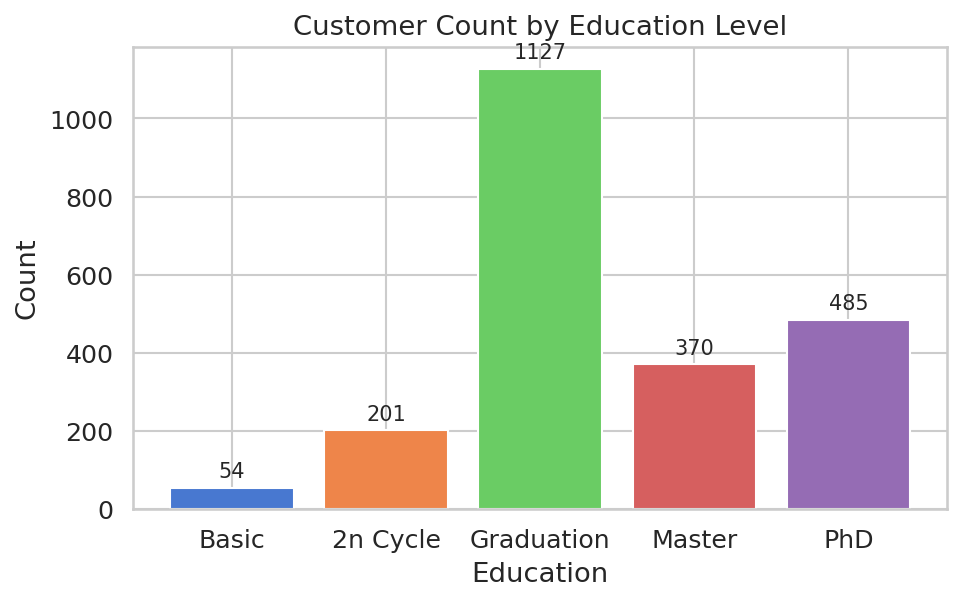

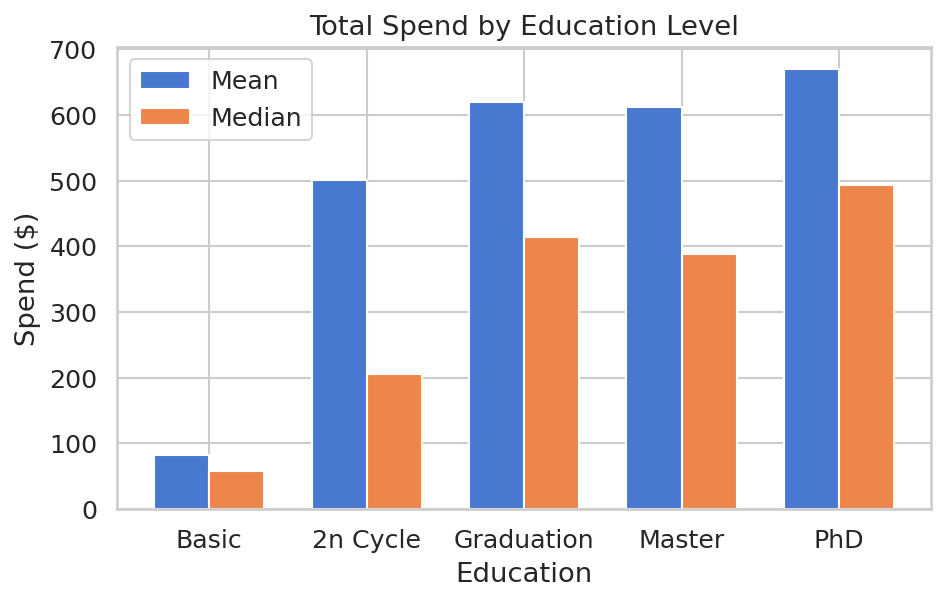

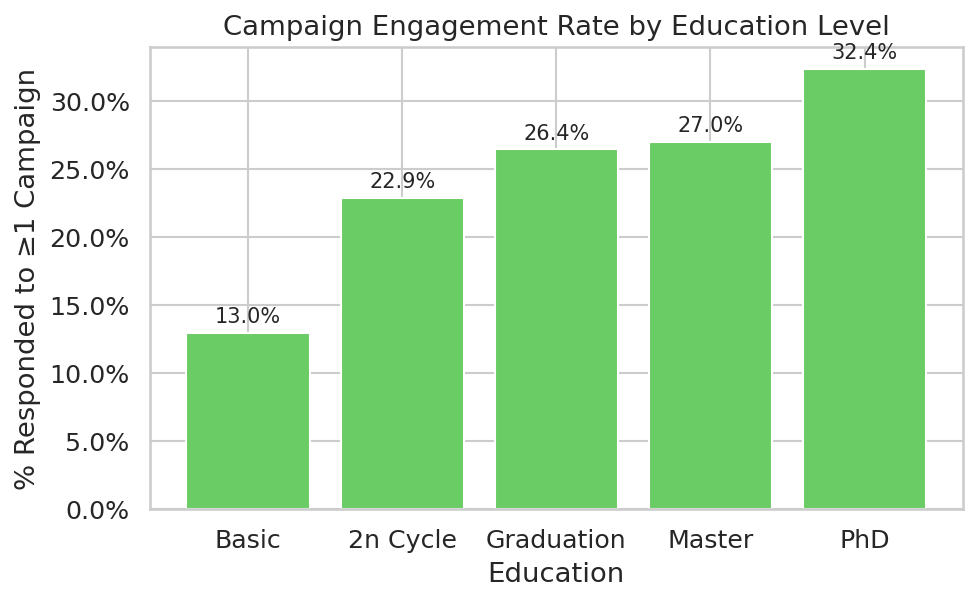

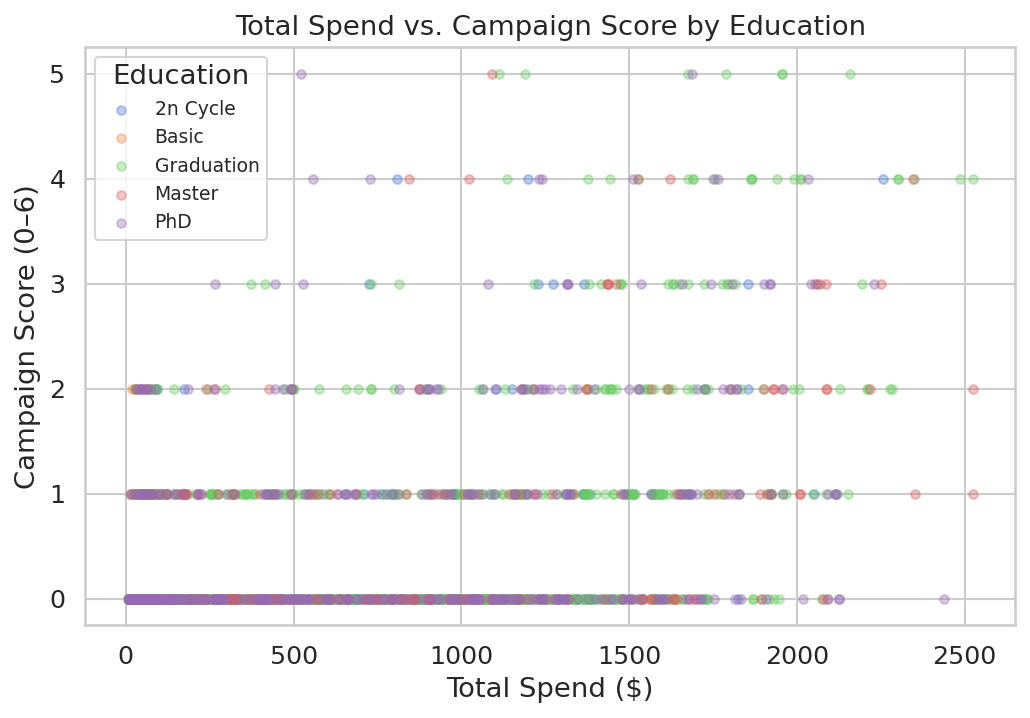

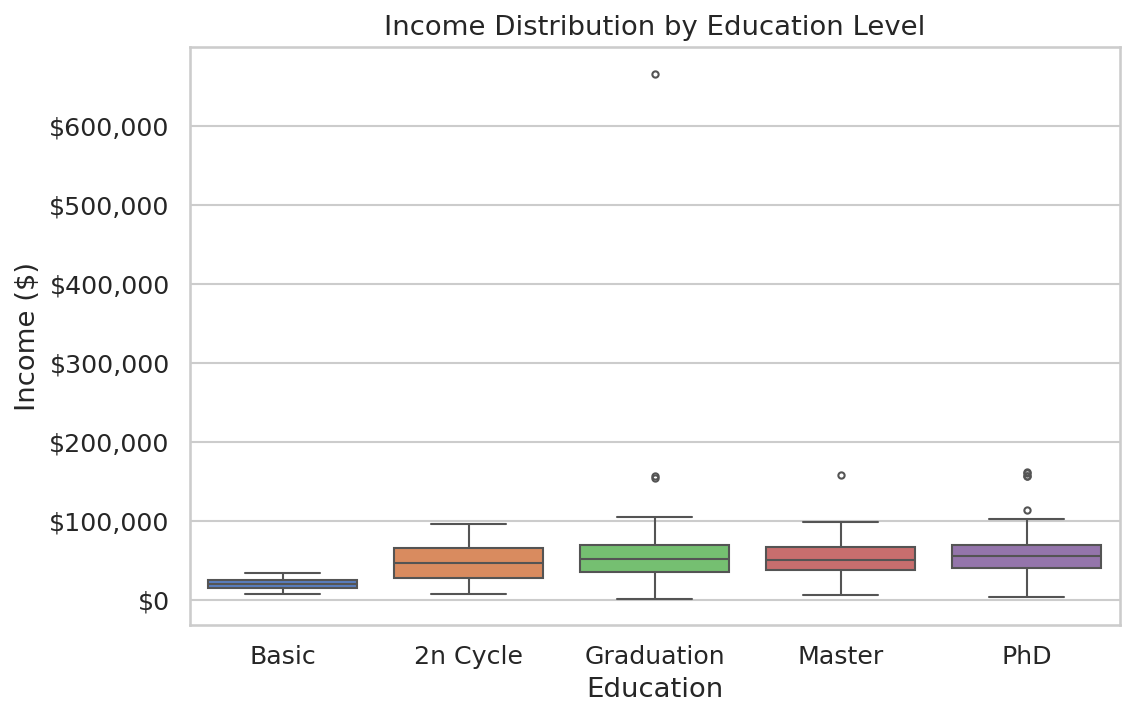

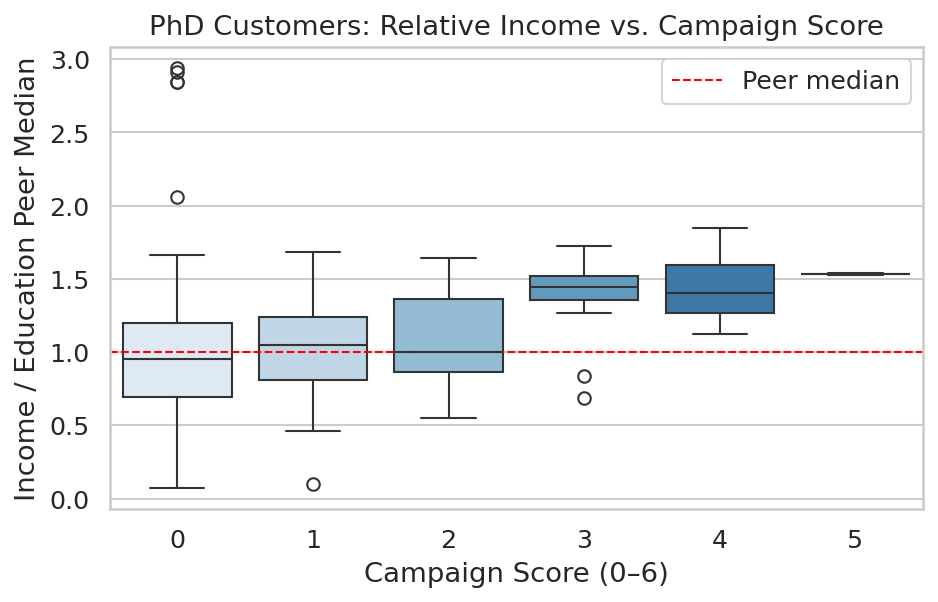

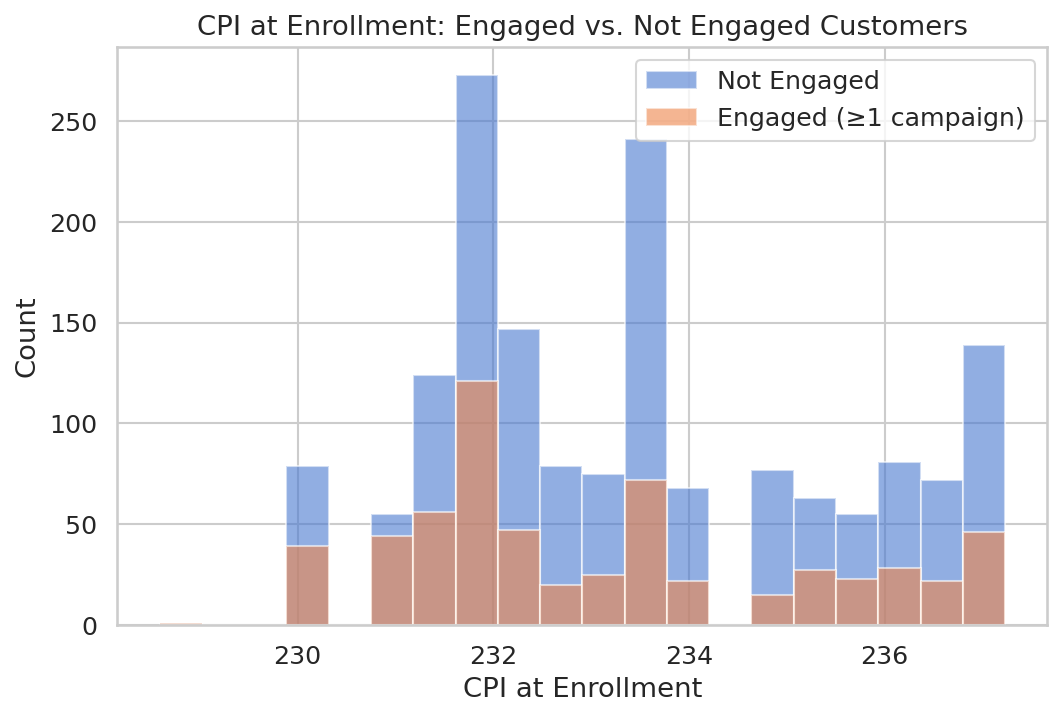

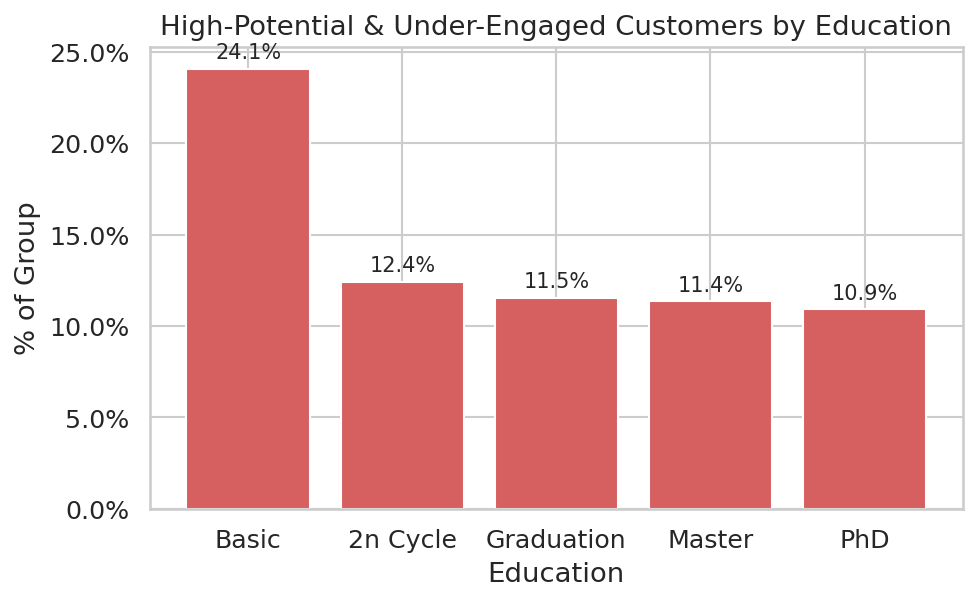

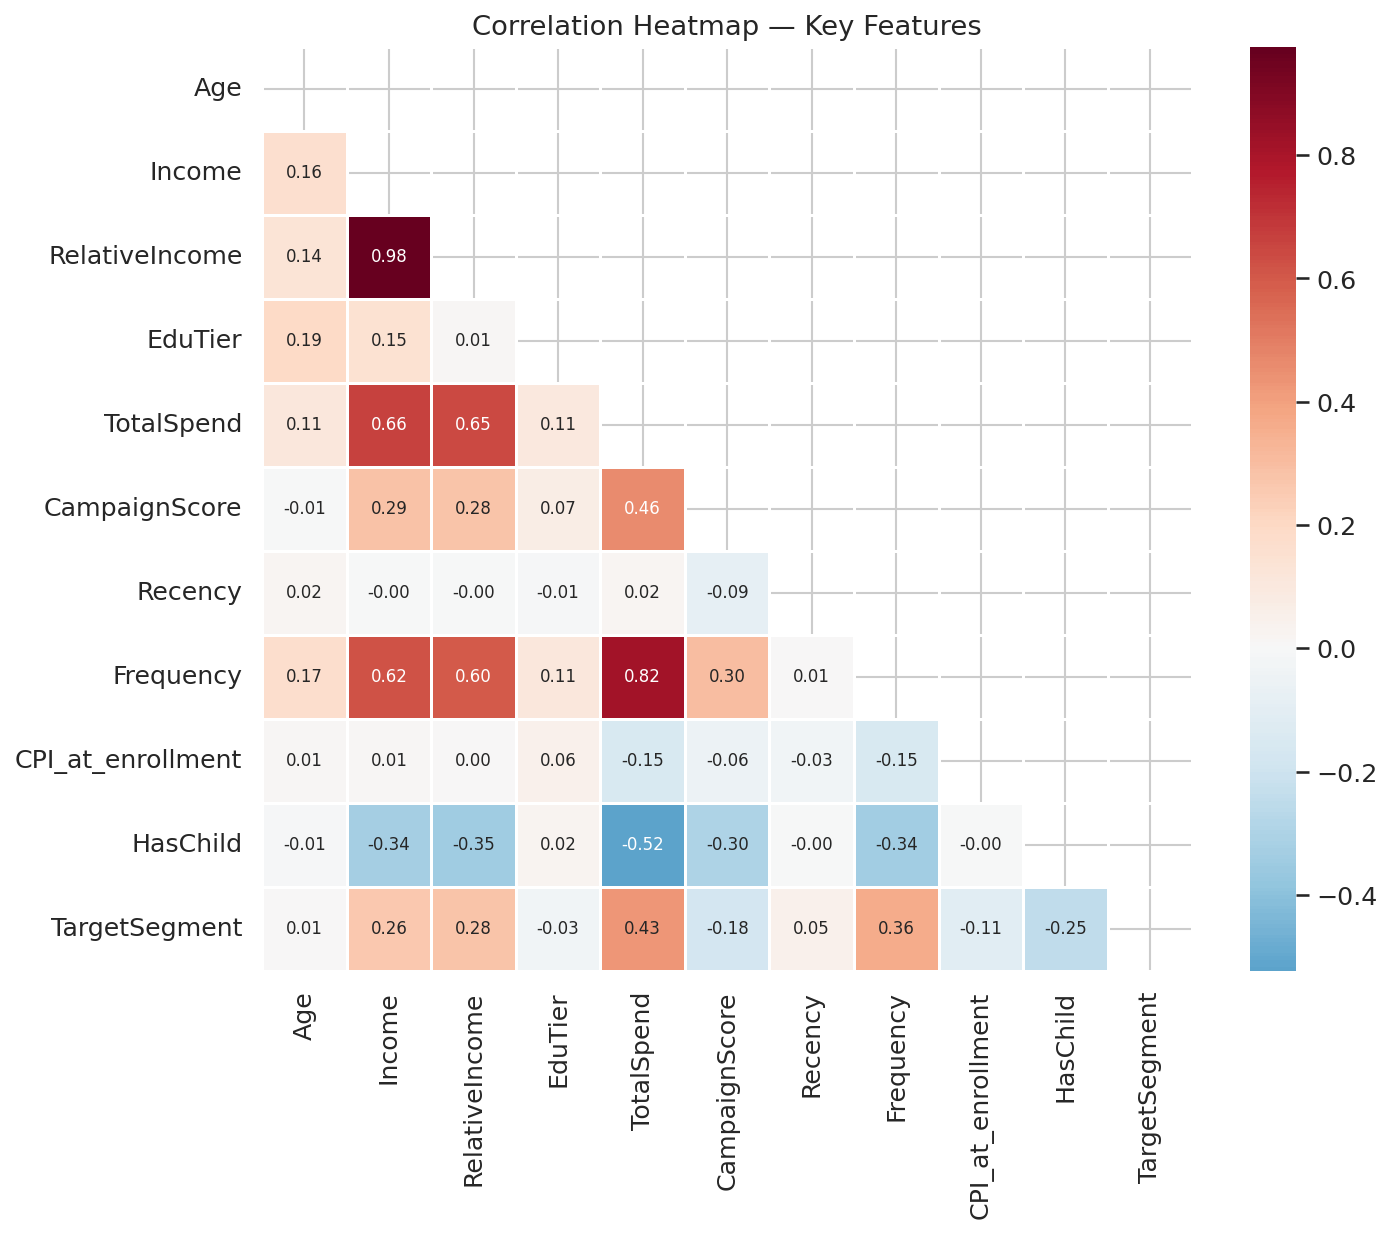

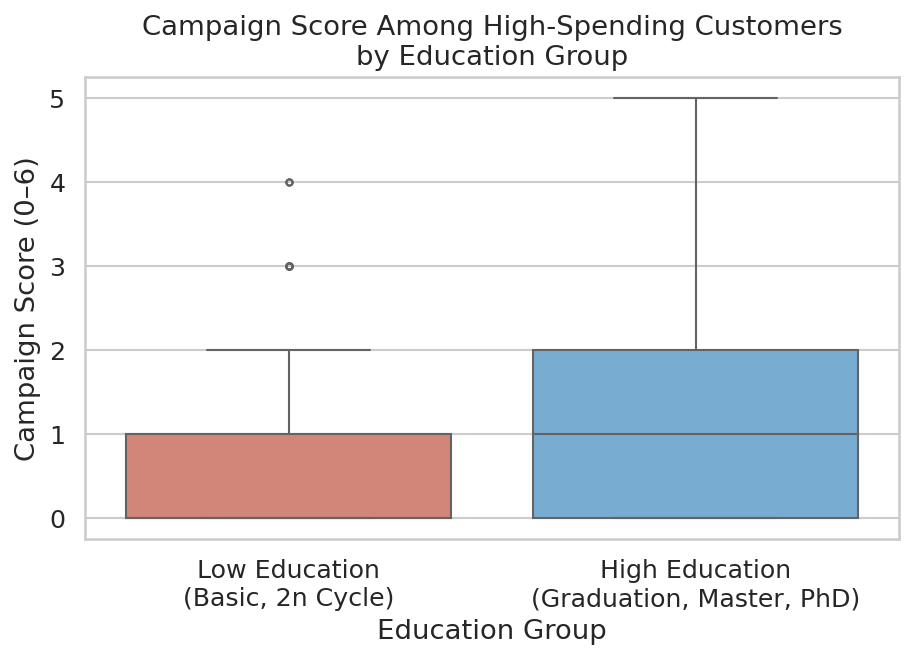

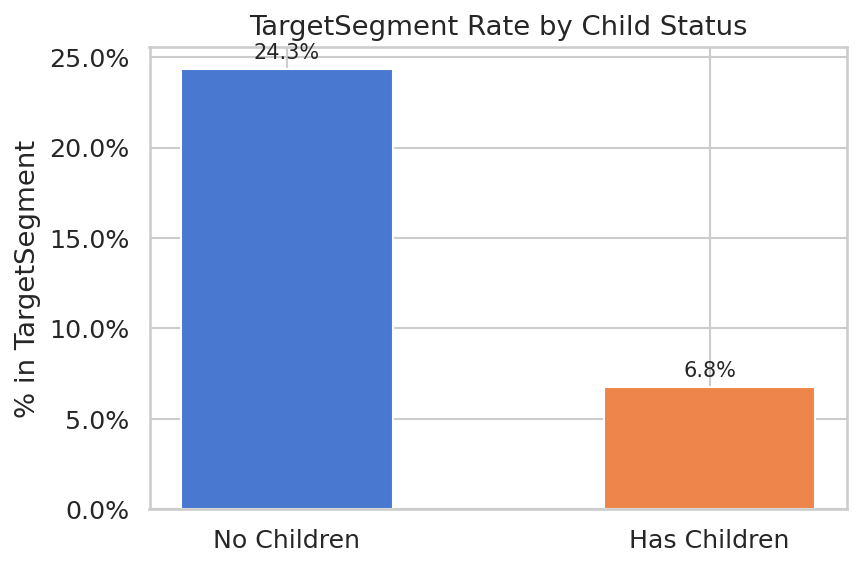

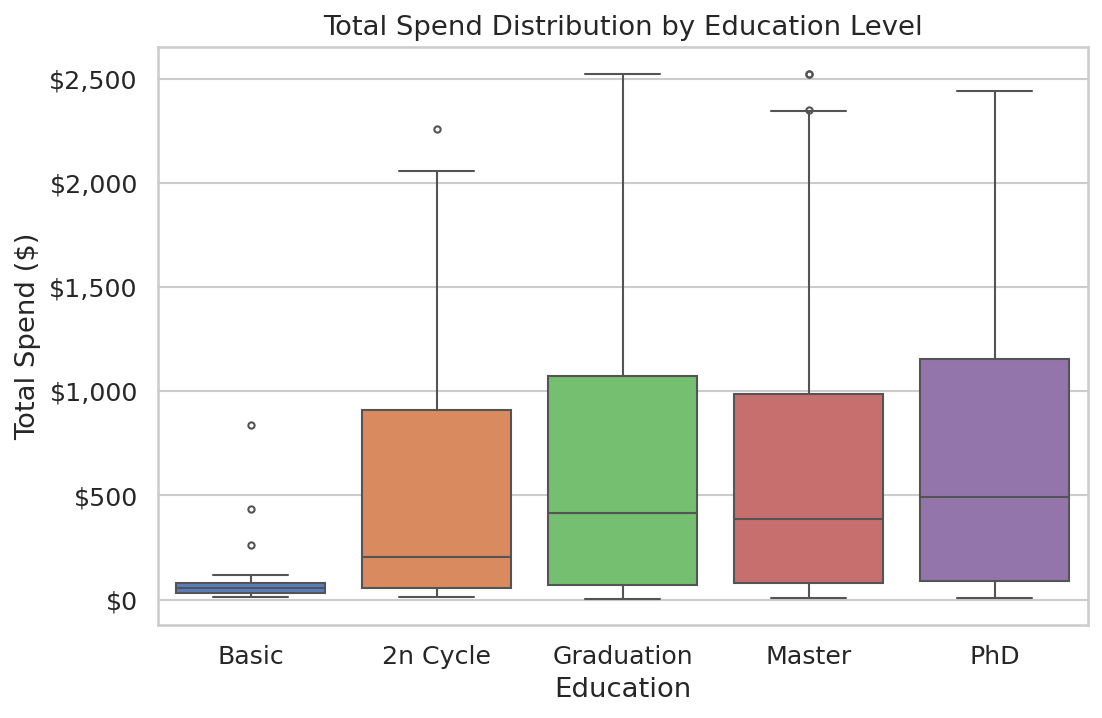

In [1]:
"""
DSA210 - Exploratory Data Analysis (EDA)
Produces visualisations saved to reports/figures/.
Run after data_preprocessing.py.
"""

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Setup ─────────────────────────────────────────────────────────────────────
PROC_DIR   = os.path.join(os.path.dirname(__file__), "data", "processed")
FIG_DIR    = os.path.join(os.path.dirname(__file__), "reports", "figures")
os.makedirs(FIG_DIR, exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
PALETTE = sns.color_palette("muted")

df = pd.read_csv(os.path.join(PROC_DIR, "customers_processed.csv"))

EDU_ORDER = ["Basic", "2n Cycle", "Graduation", "Master", "PhD"]

# ── Helper ────────────────────────────────────────────────────────────────────
def save(name):
    path = os.path.join(FIG_DIR, name)
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"  Saved → {path}")


# ═══════════════════════════════════════════════════════════════════════════════
# 1. Dataset overview
# ═══════════════════════════════════════════════════════════════════════════════
print("\n── 1. Dataset overview ──")
print(df[["Age", "Income", "TotalSpend", "CampaignScore", "Recency",
          "Frequency", "RelativeIncome", "CPI_at_enrollment"]].describe().round(2))


# ═══════════════════════════════════════════════════════════════════════════════
# 2. Education distribution
# ═══════════════════════════════════════════════════════════════════════════════
print("\n── 2. Education distribution ──")
edu_counts = df["Education"].value_counts().reindex(EDU_ORDER)
print(edu_counts)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(edu_counts.index, edu_counts.values, color=PALETTE[:5], edgecolor="white")
ax.bar_label(bars, padding=3, fontsize=10)
ax.set(title="Customer Count by Education Level", xlabel="Education", ylabel="Count")
save("01_education_distribution.png")


# ═══════════════════════════════════════════════════════════════════════════════
# 3. Total spend by education
# ═══════════════════════════════════════════════════════════════════════════════
print("\n── 3. Total spend by education ──")
spend_edu = df.groupby("Education")["TotalSpend"].agg(["mean", "median"]).reindex(EDU_ORDER)
print(spend_edu.round(0))

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(EDU_ORDER))
w = 0.35
ax.bar(x - w/2, spend_edu["mean"],   w, label="Mean",   color=PALETTE[0], edgecolor="white")
ax.bar(x + w/2, spend_edu["median"], w, label="Median", color=PALETTE[1], edgecolor="white")
ax.set_xticks(x); ax.set_xticklabels(EDU_ORDER)
ax.set(title="Total Spend by Education Level", xlabel="Education", ylabel="Spend ($)")
ax.legend()
save("02_spend_by_education.png")


# ═══════════════════════════════════════════════════════════════════════════════
# 4. Campaign engagement rate by education
# ═══════════════════════════════════════════════════════════════════════════════
print("\n── 4. Campaign engagement rate by education ──")
eng_rate = df.groupby("Education")["CampaignEngaged"].mean().reindex(EDU_ORDER) * 100
print(eng_rate.round(1))

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(eng_rate.index, eng_rate.values, color=PALETTE[2], edgecolor="white")
ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=10)
ax.set(title="Campaign Engagement Rate by Education Level",
       xlabel="Education", ylabel="% Responded to ≥1 Campaign")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
save("03_campaign_engagement_by_education.png")


# ═══════════════════════════════════════════════════════════════════════════════
# 5. Spend vs. campaign engagement across education groups (scatter)
# ═══════════════════════════════════════════════════════════════════════════════
print("\n── 5. Spend vs. campaign engagement scatter ──")
fig, ax = plt.subplots(figsize=(8, 5))
for edu, grp in df.groupby("Education"):
    ax.scatter(grp["TotalSpend"], grp["CampaignScore"],
               alpha=0.35, s=18, label=edu)
ax.set(title="Total Spend vs. Campaign Score by Education",
       xlabel="Total Spend ($)", ylabel="Campaign Score (0–6)")
ax.legend(title="Education", fontsize=9)
save("04_spend_vs_campaign_scatter.png")


# ═══════════════════════════════════════════════════════════════════════════════
# 6. Income distribution by education (box)
# ═══════════════════════════════════════════════════════════════════════════════
print("\n── 6. Income by education ──")
fig, ax = plt.subplots(figsize=(8, 5))
df_edu = df[df["Education"].isin(EDU_ORDER)].copy()
df_edu["Education"] = pd.Categorical(df_edu["Education"], categories=EDU_ORDER, ordered=True)
sns.boxplot(data=df_edu, x="Education", y="Income", order=EDU_ORDER,
            palette="muted", ax=ax, flierprops={"markersize": 3})
ax.set(title="Income Distribution by Education Level",
       xlabel="Education", ylabel="Income ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
save("05_income_by_education.png")


# ═══════════════════════════════════════════════════════════════════════════════
# 7. Relative income vs. campaign score (PhD focus)
# ═══════════════════════════════════════════════════════════════════════════════
print("\n── 7. Relative income vs campaign score (PhD) ──")
phd = df[df["Education"] == "PhD"].copy()
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=phd, x="CampaignScore", y="RelativeIncome",
            palette="Blues", ax=ax)
ax.axhline(1.0, color="red", linestyle="--", linewidth=1, label="Peer median")
ax.set(title="PhD Customers: Relative Income vs. Campaign Score",
       xlabel="Campaign Score (0–6)", ylabel="Income / Education Peer Median")
ax.legend()
save("06_phd_relative_income_vs_campaign.png")


# ═══════════════════════════════════════════════════════════════════════════════
# 8. CPI at enrollment vs. campaign engagement
# ═══════════════════════════════════════════════════════════════════════════════
print("\n── 8. CPI at enrollment vs. campaign engagement ──")
fig, ax = plt.subplots(figsize=(8, 5))
for engaged, grp in df.groupby("CampaignEngaged"):
    label = "Engaged (≥1 campaign)" if engaged else "Not Engaged"
    ax.hist(grp["CPI_at_enrollment"].dropna(), bins=20, alpha=0.6, label=label)
ax.set(title="CPI at Enrollment: Engaged vs. Not Engaged Customers",
       xlabel="CPI at Enrollment", ylabel="Count")
ax.legend()
save("07_cpi_vs_engagement.png")


# ═══════════════════════════════════════════════════════════════════════════════
# 9. Target segment breakdown
# ═══════════════════════════════════════════════════════════════════════════════
print("\n── 9. Target segment (high-potential & under-engaged) ──")
seg = df.groupby("Education")["TargetSegment"].agg(["sum", "count"])
seg["pct"] = seg["sum"] / seg["count"] * 100
seg = seg.reindex(EDU_ORDER)
print(seg.round(1))

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(seg.index, seg["pct"], color=PALETTE[3], edgecolor="white")
ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=10)
ax.set(title="High-Potential & Under-Engaged Customers by Education",
       xlabel="Education", ylabel="% of Group")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
save("08_target_segment_by_education.png")


# ═══════════════════════════════════════════════════════════════════════════════
# 10. Correlation heatmap (key features)
# ═══════════════════════════════════════════════════════════════════════════════
print("\n── 10. Correlation heatmap ──")
corr_cols = ["Age", "Income", "RelativeIncome", "EduTier", "TotalSpend",
             "CampaignScore", "Recency", "Frequency", "CPI_at_enrollment",
             "HasChild", "TargetSegment"]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, linewidths=0.5, ax=ax, annot_kws={"size": 8})
ax.set_title("Correlation Heatmap — Key Features")
save("09_correlation_heatmap.png")


# ═══════════════════════════════════════════════════════════════════════════════
# 11. H8 — Campaign score among high spenders: low vs. high education (box)
# ═══════════════════════════════════════════════════════════════════════════════
print("\n── 11. H8: Campaign score — low vs. high education among high spenders ──")
LOW_EDU  = ["Basic", "2n Cycle"]
HIGH_EDU = ["Graduation", "Master", "PhD"]

high_spenders = df[df["HighPotential"] == 1].copy()
high_spenders["EduGroup"] = high_spenders["Education"].apply(
    lambda x: "Low Education\n(Basic, 2n Cycle)" if x in LOW_EDU
              else "High Education\n(Graduation, Master, PhD)"
)

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=high_spenders, x="EduGroup", y="CampaignScore",
            palette=["#e07b6a", "#6aaee0"], ax=ax,
            order=["Low Education\n(Basic, 2n Cycle)", "High Education\n(Graduation, Master, PhD)"],
            flierprops={"markersize": 3})
ax.set(title="Campaign Score Among High-Spending Customers\nby Education Group",
       xlabel="Education Group", ylabel="Campaign Score (0–6)")
save("10_h8_campaign_score_high_spenders.png")


# ═══════════════════════════════════════════════════════════════════════════════
# 12. H9 — HasChild x TargetSegment (grouped bar)
# ═══════════════════════════════════════════════════════════════════════════════
print("\n── 12. H9: HasChild vs. TargetSegment ──")
child_seg = df.groupby("HasChild")["TargetSegment"].mean() * 100
child_seg.index = ["No Children", "Has Children"]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(child_seg.index, child_seg.values,
              color=[PALETTE[0], PALETTE[1]], edgecolor="white", width=0.5)
ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=10)
ax.set(title="TargetSegment Rate by Child Status",
       xlabel="", ylabel="% in TargetSegment")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
save("11_h9_haschild_vs_targetsegment.png")


# ═══════════════════════════════════════════════════════════════════════════════
# 13. H10 — Total spend distribution across education groups (box)
# ═══════════════════════════════════════════════════════════════════════════════
print("\n── 13. H10: Total spend by education (box) ──")
df_edu2 = df[df["Education"].isin(EDU_ORDER)].copy()
df_edu2["Education"] = pd.Categorical(df_edu2["Education"], categories=EDU_ORDER, ordered=True)

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df_edu2, x="Education", y="TotalSpend", order=EDU_ORDER,
            palette="muted", ax=ax, flierprops={"markersize": 3})
ax.set(title="Total Spend Distribution by Education Level",
       xlabel="Education", ylabel="Total Spend ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
save("12_h10_spend_by_education_box.png")


print("\n✓ EDA complete. All figures saved to reports/figures/")


---
## Step 3: Hypothesis Testing

In [1]:
"""
DSA210 - Hypothesis Tests
Tests whether education level, income, and CPI at enrollment
explain campaign disengagement among high-spending customers.
Run after data_preprocessing.py.
"""

import os
import pandas as pd
import numpy as np
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# ── Setup ─────────────────────────────────────────────────────────────────────
PROC_DIR = os.path.join(os.path.dirname(__file__), "data", "processed")
df = pd.read_csv(os.path.join(PROC_DIR, "customers_processed.csv"))

EDU_ORDER  = ["Basic", "2n Cycle", "Graduation", "Master", "PhD"]
LOW_EDU    = ["Basic", "2n Cycle"]
HIGH_EDU   = ["Graduation", "Master", "PhD"]

def separator(title):
    print(f"\n{'═'*60}")
    print(f"  {title}")
    print('═'*60)

def result(reject, p, alpha=0.05):
    decision = "REJECT H₀" if reject else "FAIL TO REJECT H₀"
    sig = "✓ Significant" if reject else "✗ Not significant"
    print(f"  p-value  : {p:.4f}  (α = {alpha})")
    print(f"  Decision : {decision}  →  {sig}")


# ═══════════════════════════════════════════════════════════════════════════════
# H1 — Does education level affect campaign engagement rate?
#      Chi-square test of independence: Education × CampaignEngaged
# ═══════════════════════════════════════════════════════════════════════════════
separator("H1 — Education level vs. campaign engagement")
print("  H₀: Campaign engagement is independent of education level")
print("  H₁: Campaign engagement differs across education levels")

contingency = pd.crosstab(df["Education"], df["CampaignEngaged"])
print("\n  Contingency table (Not Engaged | Engaged):")
print(contingency.reindex(EDU_ORDER))

chi2, p_chi2, dof, expected = stats.chi2_contingency(contingency)
print(f"\n  χ²({dof}) = {chi2:.3f}")
result(p_chi2 < 0.05, p_chi2)

# Effect size: Cramér's V
n = contingency.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))
print(f"  Cramér's V : {cramers_v:.3f}  ({'small' if cramers_v < 0.1 else 'medium' if cramers_v < 0.3 else 'large'} effect)")


# ═══════════════════════════════════════════════════════════════════════════════
# H2 — Do PhD customers spend more than non-PhD customers?
#      Mann-Whitney U test (non-parametric, spend is skewed)
# ═══════════════════════════════════════════════════════════════════════════════
separator("H2 — PhD customers vs. others: total spend")
print("  H₀: Median total spend is equal for PhD and non-PhD customers")
print("  H₁: PhD customers have higher median total spend")

phd_spend     = df[df["Education"] == "PhD"]["TotalSpend"]
non_phd_spend = df[df["Education"] != "PhD"]["TotalSpend"]

print(f"\n  PhD     — n={len(phd_spend):,}, median=${phd_spend.median():.0f}, mean=${phd_spend.mean():.0f}")
print(f"  Non-PhD — n={len(non_phd_spend):,}, median=${non_phd_spend.median():.0f}, mean=${non_phd_spend.mean():.0f}")

u_stat, p_mw = stats.mannwhitneyu(phd_spend, non_phd_spend, alternative="greater")
print(f"\n  Mann-Whitney U = {u_stat:.0f}")
result(p_mw < 0.05, p_mw)

# Effect size: rank-biserial correlation
n1, n2 = len(phd_spend), len(non_phd_spend)
r_rb = 1 - (2 * u_stat) / (n1 * n2)
print(f"  Rank-biserial r : {r_rb:.3f}")


# ═══════════════════════════════════════════════════════════════════════════════
# H3 — Among PhD customers, do campaign-engaged and non-engaged differ in spend?
#      Mann-Whitney U test
# ═══════════════════════════════════════════════════════════════════════════════
separator("H3 — PhD: engaged vs. non-engaged customers: total spend")
print("  H₀: Among PhD customers, spend is equal regardless of campaign engagement")
print("  H₁: Non-engaged PhD customers spend more (campaign-immune high spenders)")

phd = df[df["Education"] == "PhD"]
phd_engaged     = phd[phd["CampaignEngaged"] == 1]["TotalSpend"]
phd_not_engaged = phd[phd["CampaignEngaged"] == 0]["TotalSpend"]

print(f"\n  Engaged     — n={len(phd_engaged):,}, median=${phd_engaged.median():.0f}")
print(f"  Not Engaged — n={len(phd_not_engaged):,}, median=${phd_not_engaged.median():.0f}")

u_stat3, p_mw3 = stats.mannwhitneyu(phd_not_engaged, phd_engaged, alternative="greater")
print(f"\n  Mann-Whitney U = {u_stat3:.0f}")
result(p_mw3 < 0.05, p_mw3)


# ═══════════════════════════════════════════════════════════════════════════════
# H4 — Does relative income differ between campaign-engaged and non-engaged
#      customers within the PhD group?
#      Mann-Whitney U test
# ═══════════════════════════════════════════════════════════════════════════════
separator("H4 — PhD: relative income vs. campaign engagement")
print("  H₀: Relative income is equal for engaged and non-engaged PhD customers")
print("  H₁: Non-engaged PhD customers have higher relative income")

phd_eng_ri  = phd[phd["CampaignEngaged"] == 1]["RelativeIncome"]
phd_neng_ri = phd[phd["CampaignEngaged"] == 0]["RelativeIncome"]

print(f"\n  Engaged     — median relative income = {phd_eng_ri.median():.3f}")
print(f"  Not Engaged — median relative income = {phd_neng_ri.median():.3f}")

u_stat4, p_mw4 = stats.mannwhitneyu(phd_neng_ri, phd_eng_ri, alternative="greater")
print(f"\n  Mann-Whitney U = {u_stat4:.0f}")
result(p_mw4 < 0.05, p_mw4)


# ═══════════════════════════════════════════════════════════════════════════════
# H5 — Does CPI at enrollment differ between campaign-engaged and
#      non-engaged customers (full dataset)?
#      Mann-Whitney U test
# ═══════════════════════════════════════════════════════════════════════════════
separator("H5 — CPI at enrollment vs. campaign engagement")
print("  H₀: CPI at enrollment is equal for engaged and non-engaged customers")
print("  H₁: CPI at enrollment differs between the two groups")

cpi_eng  = df[df["CampaignEngaged"] == 1]["CPI_at_enrollment"].dropna()
cpi_neng = df[df["CampaignEngaged"] == 0]["CPI_at_enrollment"].dropna()

print(f"\n  Engaged     — n={len(cpi_eng):,}, median CPI = {cpi_eng.median():.2f}")
print(f"  Not Engaged — n={len(cpi_neng):,}, median CPI = {cpi_neng.median():.2f}")

u_stat5, p_mw5 = stats.mannwhitneyu(cpi_eng, cpi_neng, alternative="two-sided")
print(f"\n  Mann-Whitney U = {u_stat5:.0f}")
result(p_mw5 < 0.05, p_mw5)


# ═══════════════════════════════════════════════════════════════════════════════
# H6 — Kruskal-Wallis: does campaign score differ across education groups?
#      Non-parametric one-way ANOVA equivalent
# ═══════════════════════════════════════════════════════════════════════════════
separator("H6 — Campaign score across all education groups (Kruskal-Wallis)")
print("  H₀: Campaign score distribution is the same across all education levels")
print("  H₁: At least one education group differs in campaign score")

groups = [df[df["Education"] == edu]["CampaignScore"].values for edu in EDU_ORDER]
for edu, grp in zip(EDU_ORDER, groups):
    print(f"  {edu:<12} — median={np.median(grp):.2f}, mean={np.mean(grp):.2f}")

h_stat, p_kw = stats.kruskal(*groups)
print(f"\n  Kruskal-Wallis H = {h_stat:.3f}")
result(p_kw < 0.05, p_kw)

# Post-hoc pairwise Mann-Whitney with Bonferroni correction
print("\n  Post-hoc pairwise Mann-Whitney (Bonferroni corrected):")
n_pairs = len(EDU_ORDER) * (len(EDU_ORDER) - 1) // 2
alpha_bonf = 0.05 / n_pairs
print(f"  Bonferroni α = {alpha_bonf:.4f}  ({n_pairs} comparisons)\n")

for i in range(len(EDU_ORDER)):
    for j in range(i + 1, len(EDU_ORDER)):
        e1, e2 = EDU_ORDER[i], EDU_ORDER[j]
        g1 = df[df["Education"] == e1]["CampaignScore"]
        g2 = df[df["Education"] == e2]["CampaignScore"]
        u, p = stats.mannwhitneyu(g1, g2, alternative="two-sided")
        sig = "✓" if p < alpha_bonf else " "
        print(f"  {sig} {e1:<12} vs {e2:<12} — p={p:.4f}")


# ═══════════════════════════════════════════════════════════════════════════════
# H7 — Does TargetSegment rate differ across education groups?
#      Chi-square test of independence: Education × TargetSegment
# ═══════════════════════════════════════════════════════════════════════════════
separator("H7 — TargetSegment rate across education groups (χ²)")
print("  H₀: TargetSegment membership is independent of education level")
print("  H₁: TargetSegment rate differs across education levels")
print("  (Motivation: Basic=24.1%, 2n Cycle=12.4%, Graduation=11.5%,")
print("               Master=11.4%, PhD=10.9% — is this gap significant?)")

contingency7 = pd.crosstab(df["Education"], df["TargetSegment"])
print("\n  Contingency table (Not Target | Target):")
print(contingency7.reindex(EDU_ORDER))

chi2_7, p_chi2_7, dof7, _ = stats.chi2_contingency(contingency7)
print(f"\n  χ²({dof7}) = {chi2_7:.3f}")
result(p_chi2_7 < 0.05, p_chi2_7)

n7 = contingency7.sum().sum()
cramers_v7 = np.sqrt(chi2_7 / (n7 * (min(contingency7.shape) - 1)))
print(f"  Cramér's V : {cramers_v7:.3f}  ({'small' if cramers_v7 < 0.1 else 'medium' if cramers_v7 < 0.3 else 'large'} effect)")


# ═══════════════════════════════════════════════════════════════════════════════
# H8 — Do lower-education high-spenders engage less with campaigns than
#      higher-education high-spenders?
#      Mann-Whitney U test on CampaignScore among high-spending customers only
# ═══════════════════════════════════════════════════════════════════════════════
separator("H8 — Low vs. high education: campaign engagement among high spenders")
print("  H₀: Among high-spending customers, campaign score is equal across")
print("      low-education (Basic, 2n Cycle) and high-education groups")
print("  H₁: High-spending low-education customers have lower campaign scores")
print("      (i.e., engagement does not scale uniformly with education)")

high_spenders = df[df["HighPotential"] == 1]
low_edu_cs  = high_spenders[high_spenders["Education"].isin(LOW_EDU)]["CampaignScore"]
high_edu_cs = high_spenders[high_spenders["Education"].isin(HIGH_EDU)]["CampaignScore"]

print(f"\n  Low education  (Basic, 2n Cycle) — n={len(low_edu_cs):,}, median={low_edu_cs.median():.2f}")
print(f"  High education (Grad, Master, PhD) — n={len(high_edu_cs):,}, median={high_edu_cs.median():.2f}")

u_stat8, p_mw8 = stats.mannwhitneyu(low_edu_cs, high_edu_cs, alternative="less")
print(f"\n  Mann-Whitney U = {u_stat8:.0f}")
result(p_mw8 < 0.05, p_mw8)

n8a, n8b = len(low_edu_cs), len(high_edu_cs)
r_rb8 = 1 - (2 * u_stat8) / (n8a * n8b)
print(f"  Rank-biserial r : {r_rb8:.3f}")


# ═══════════════════════════════════════════════════════════════════════════════
# H9 — Is having children associated with TargetSegment membership?
#      Chi-square test of independence: HasChild × TargetSegment
# ═══════════════════════════════════════════════════════════════════════════════
separator("H9 — HasChild vs. TargetSegment membership (χ²)")
print("  H₀: TargetSegment membership is independent of having children")
print("  H₁: Customers with children are more/less likely to be in TargetSegment")
print("  (Motivation: HasChild correlates -0.52 with TotalSpend in heatmap)")

contingency9 = pd.crosstab(df["HasChild"], df["TargetSegment"])
contingency9.index = ["No Children", "Has Children"]
contingency9.columns = ["Not Target", "Target"]
print("\n  Contingency table:")
print(contingency9)

chi2_9, p_chi2_9, dof9, _ = stats.chi2_contingency(contingency9)
print(f"\n  χ²({dof9}) = {chi2_9:.3f}")
result(p_chi2_9 < 0.05, p_chi2_9)

n9 = contingency9.sum().sum()
cramers_v9 = np.sqrt(chi2_9 / (n9 * (min(contingency9.shape) - 1)))
print(f"  Cramér's V : {cramers_v9:.3f}  ({'small' if cramers_v9 < 0.1 else 'medium' if cramers_v9 < 0.3 else 'large'} effect)")

# Observed rates
for label, row in contingency9.iterrows():
    rate = row["Target"] / row.sum() * 100
    print(f"  {label:<15} — TargetSegment rate: {rate:.1f}%")


# ═══════════════════════════════════════════════════════════════════════════════
# H10 — Does total spend differ across all education groups?
#       Kruskal-Wallis + post-hoc (non-parametric one-way ANOVA on spend)
# ═══════════════════════════════════════════════════════════════════════════════
separator("H10 — Total spend across all education groups (Kruskal-Wallis)")
print("  H₀: Total spend distribution is the same across all education levels")
print("  H₁: At least one education group differs in total spend")

spend_groups = [df[df["Education"] == edu]["TotalSpend"].values for edu in EDU_ORDER]
for edu, grp in zip(EDU_ORDER, spend_groups):
    print(f"  {edu:<12} — median=${np.median(grp):.0f}, mean=${np.mean(grp):.0f}")

h_stat10, p_kw10 = stats.kruskal(*spend_groups)
print(f"\n  Kruskal-Wallis H = {h_stat10:.3f}")
result(p_kw10 < 0.05, p_kw10)

# Post-hoc pairwise Mann-Whitney with Bonferroni correction
print("\n  Post-hoc pairwise Mann-Whitney (Bonferroni corrected):")
n_pairs10 = len(EDU_ORDER) * (len(EDU_ORDER) - 1) // 2
alpha_bonf10 = 0.05 / n_pairs10
print(f"  Bonferroni α = {alpha_bonf10:.4f}  ({n_pairs10} comparisons)\n")

for i in range(len(EDU_ORDER)):
    for j in range(i + 1, len(EDU_ORDER)):
        e1, e2 = EDU_ORDER[i], EDU_ORDER[j]
        g1 = df[df["Education"] == e1]["TotalSpend"]
        g2 = df[df["Education"] == e2]["TotalSpend"]
        u, p = stats.mannwhitneyu(g1, g2, alternative="two-sided")
        sig = "✓" if p < alpha_bonf10 else " "
        print(f"  {sig} {e1:<12} vs {e2:<12} — p={p:.4f}")


# ═══════════════════════════════════════════════════════════════════════════════
# Summary
# ═══════════════════════════════════════════════════════════════════════════════
separator("SUMMARY")
results_summary = [
    ("H1",  "Education × Campaign engagement (χ²)",            p_chi2),
    ("H2",  "PhD vs. non-PhD total spend (MW)",                 p_mw),
    ("H3",  "PhD engaged vs. non-engaged spend (MW)",           p_mw3),
    ("H4",  "PhD engaged vs. non-engaged relative income (MW)", p_mw4),
    ("H5",  "CPI at enrollment × engagement (MW)",              p_mw5),
    ("H6",  "Campaign score across education (KW)",             p_kw),
    ("H7",  "TargetSegment rate across education (χ²)",         p_chi2_7),
    ("H8",  "Low vs. high edu campaign score — high spenders",  p_mw8),
    ("H9",  "HasChild × TargetSegment membership (χ²)",         p_chi2_9),
    ("H10", "Total spend across education groups (KW)",         p_kw10),
]
print(f"\n  {'Test':<6} {'Description':<48} {'p-value':<10} {'Significant?'}")
print("  " + "-"*75)
for test, desc, p in results_summary:
    sig = "Yes ✓" if p < 0.05 else "No  ✗"
    print(f"  {test:<6} {desc:<48} {p:<10.4f} {sig}")

print("\n✓ Hypothesis tests complete.")



════════════════════════════════════════════════════════════
  H1 — Education level vs. campaign engagement
════════════════════════════════════════════════════════════
  H₀: Campaign engagement is independent of education level
  H₁: Campaign engagement differs across education levels
  χ²(4) = 14.306
  p-value  : 0.0064  (α = 0.05)
  Decision : REJECT H₀  →  ✓ Significant
  Cramér's V : 0.080  (small effect)

════════════════════════════════════════════════════════════
  H2 — PhD customers vs. others: total spend
════════════════════════════════════════════════════════════
  PhD     — n=485, median=$493, mean=$670
  Non-PhD — n=1,752, median=$350, mean=$588
  Mann-Whitney U = 459720
  p-value  : 0.0028  (α = 0.05)
  Decision : REJECT H₀  →  ✓ Significant

════════════════════════════════════════════════════════════
  H3 — PhD: engaged vs. non-engaged spend
════════════════════════════════════════════════════════════
  Engaged     — n=157, median=$972
  Not Engaged — n=328, median=$2

---
## Step 4: Machine Learning Models

Dataset: 2237 rows | Target class balance: 11.8% positive


═══ CLASSIFICATION MODELS ═══

───────────────────────────────────────────────────────
  Logistic Regression (baseline)
───────────────────────────────────────────────────────
               precision    recall  f1-score   support

   Non-Target       0.99      0.79      0.88       395
TargetSegment       0.37      0.92      0.53        53

     accuracy                           0.81       448
    macro avg       0.68      0.86      0.71       448
 weighted avg       0.91      0.81      0.84       448

  ROC-AUC (test)  : 0.8711
  ROC-AUC (5-fold CV): 0.8853 ± 0.0133

───────────────────────────────────────────────────────
  Decision Tree
───────────────────────────────────────────────────────
               precision    recall  f1-score   support

   Non-Target       0.98      0.85      0.91       395
TargetSegment       0.44      0.85      0.58        53

     accuracy                           0.85       448
  ROC-AUC (tes

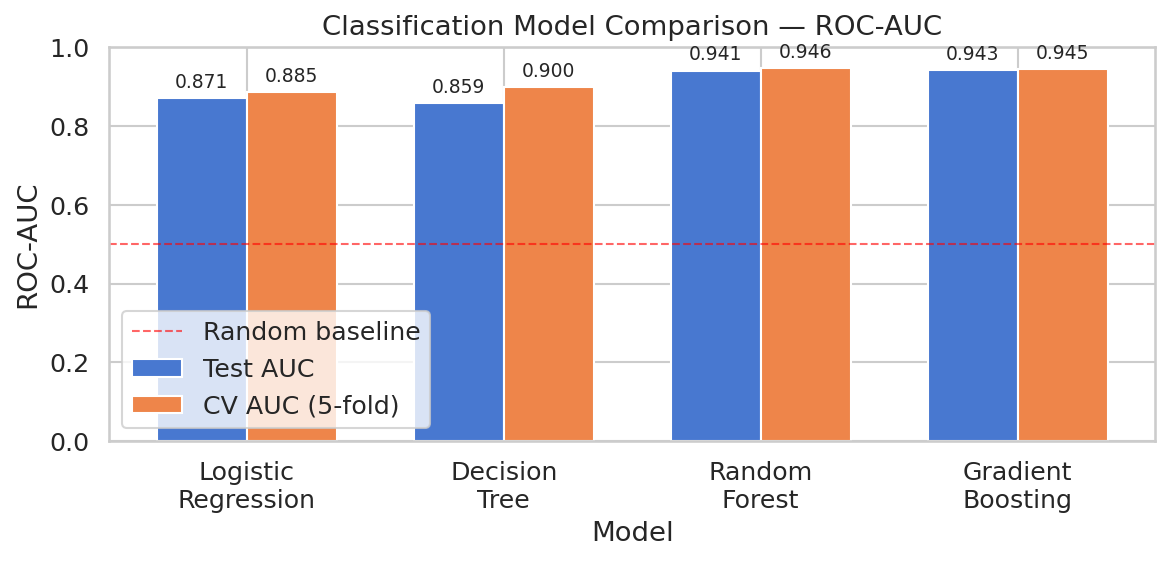

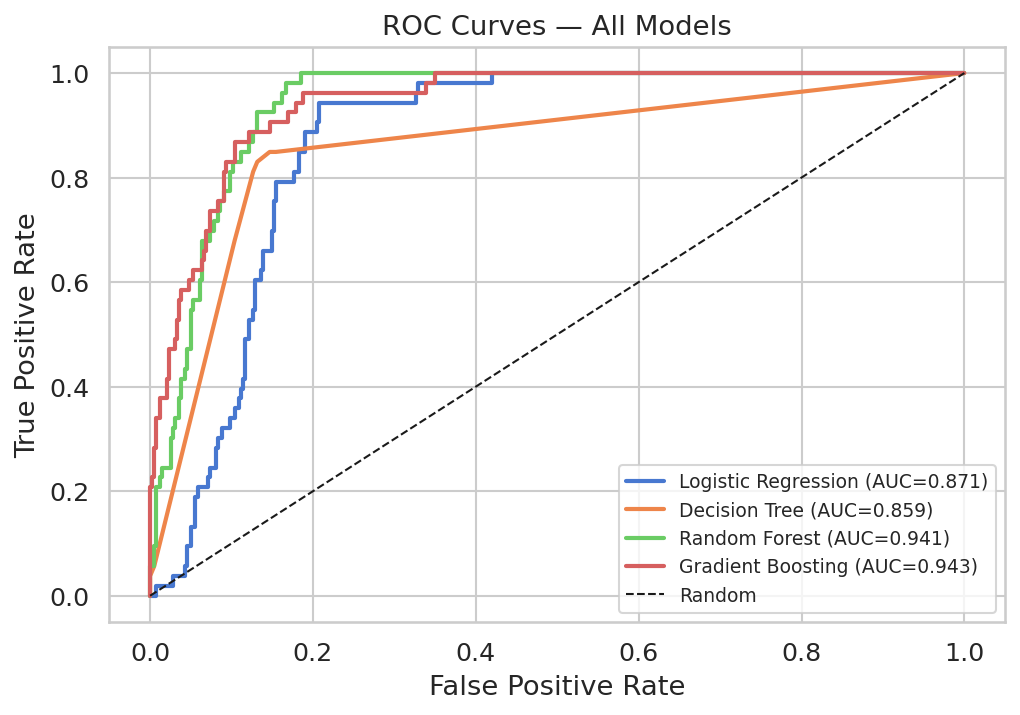

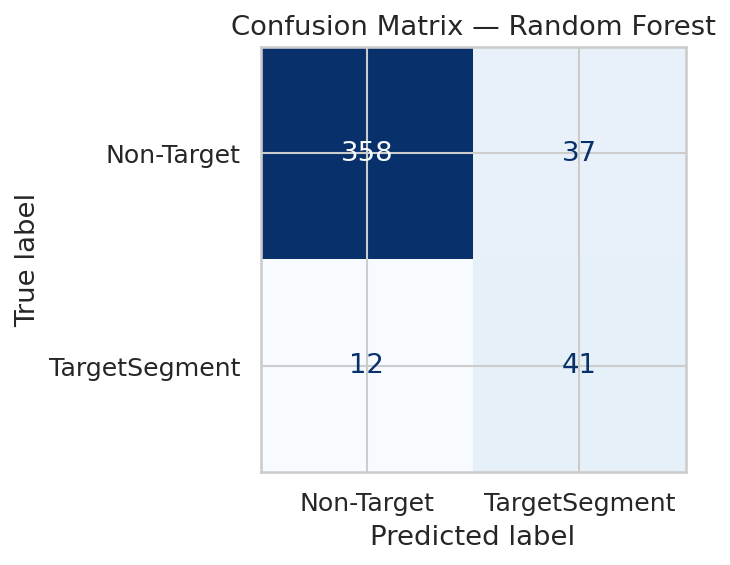

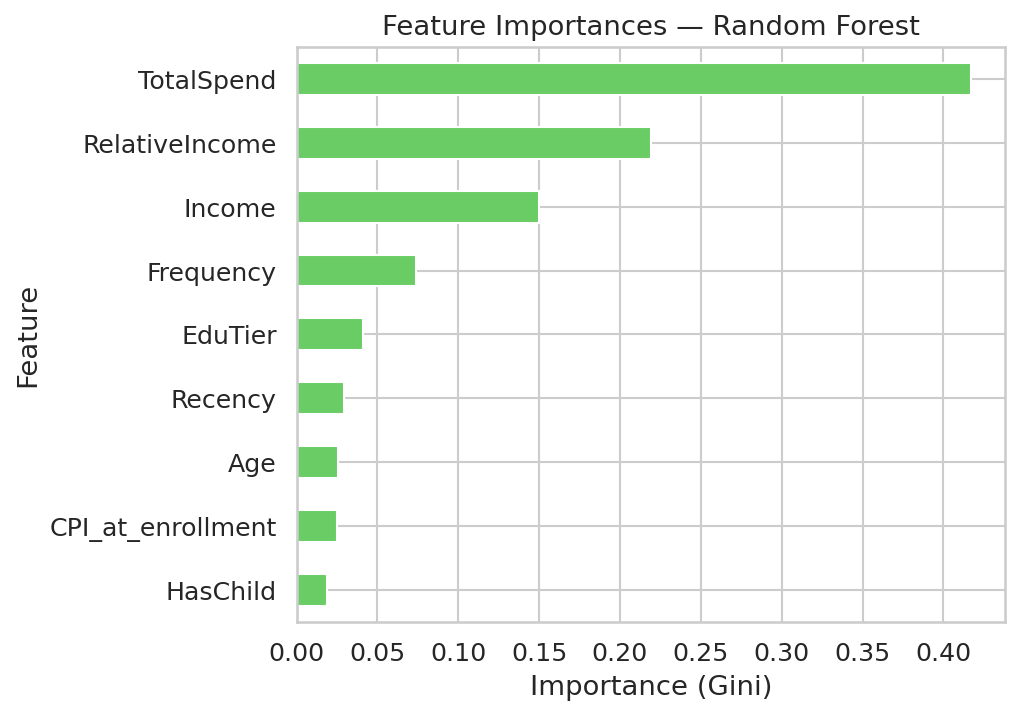

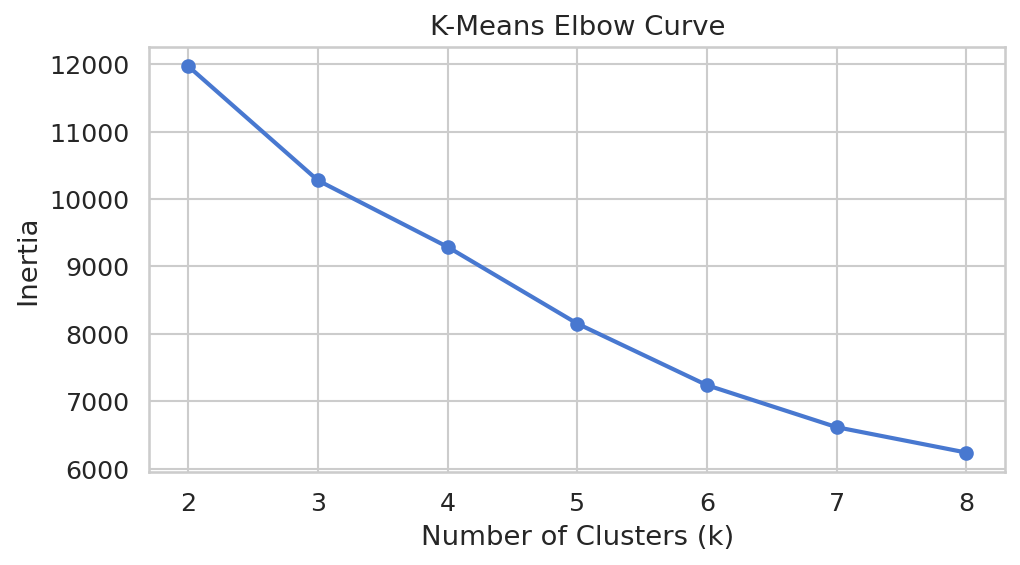

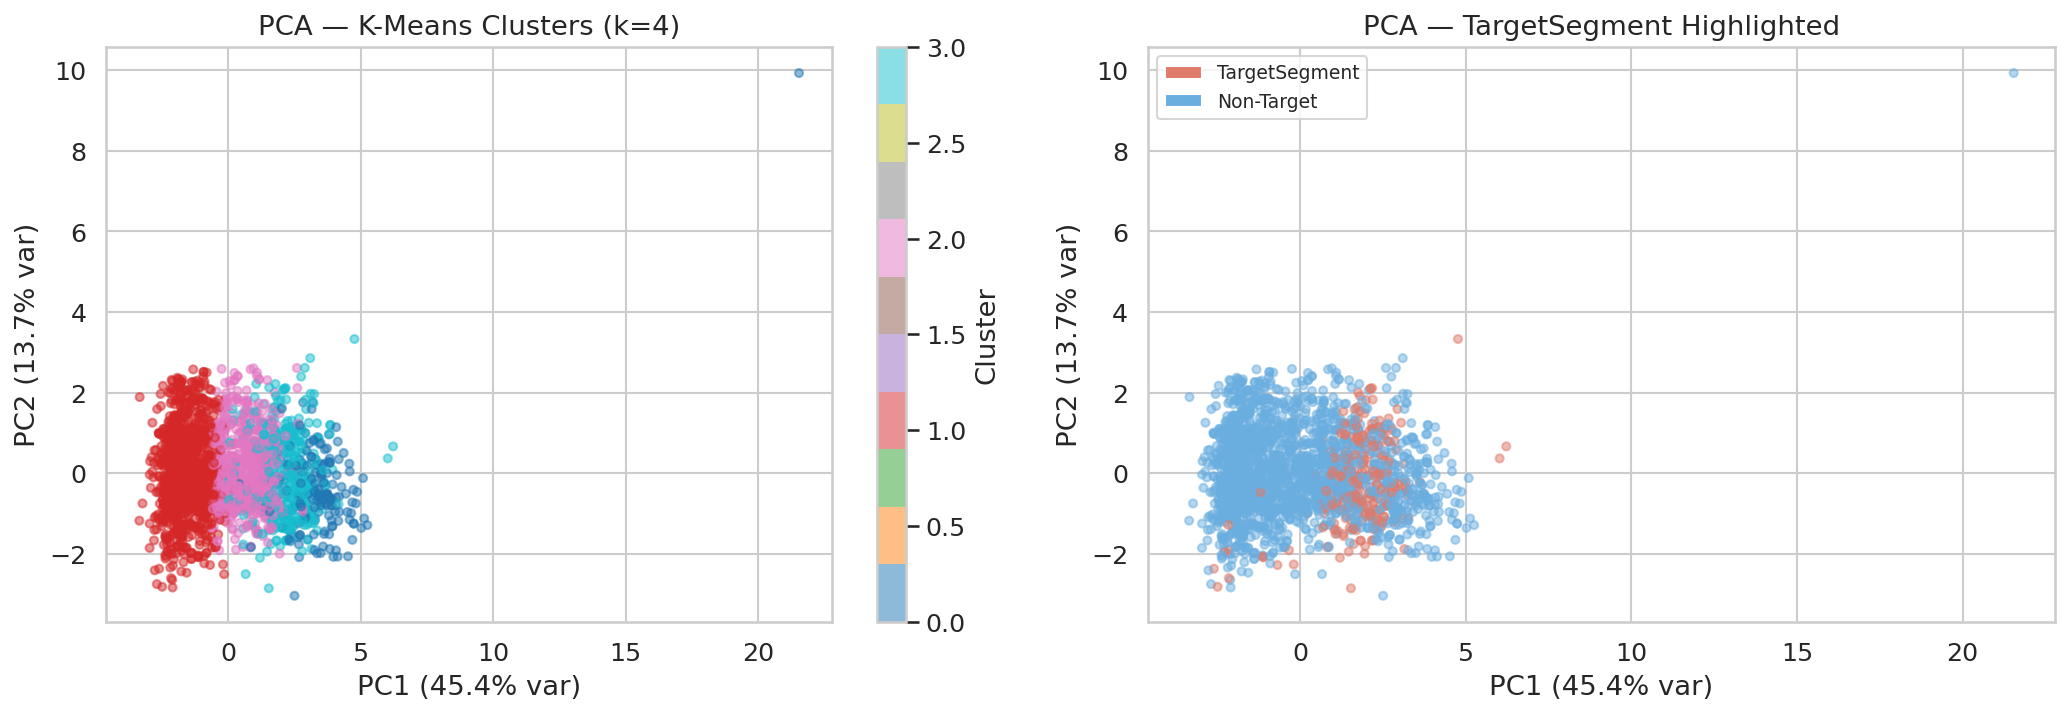

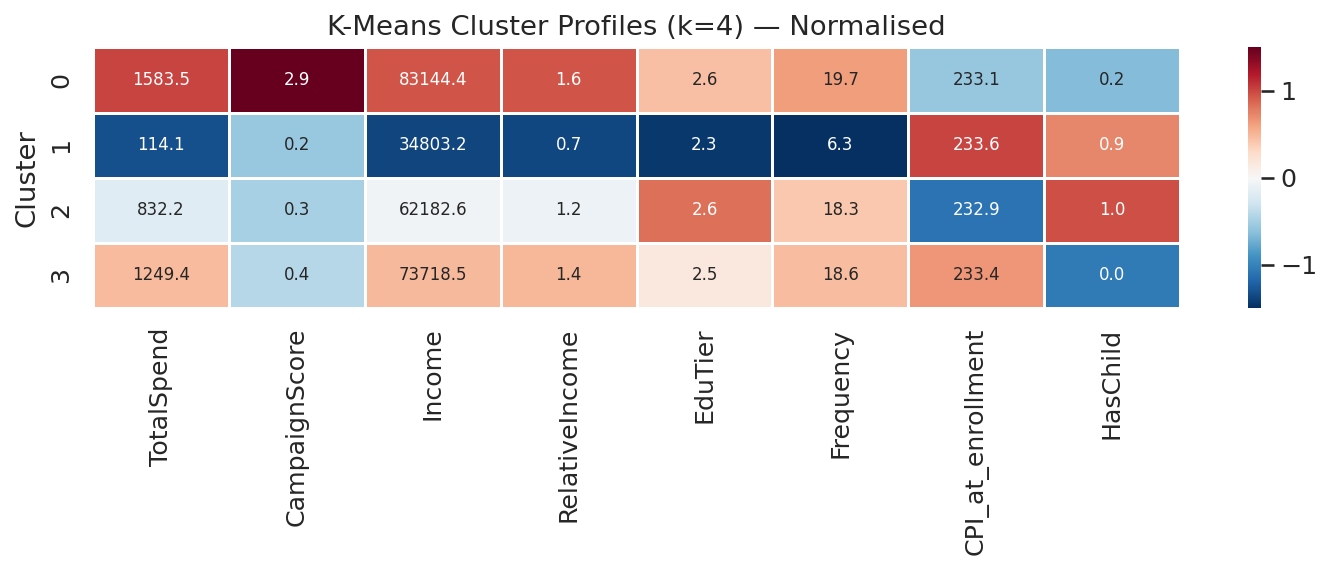

In [1]:
"""
DSA210 - Machine Learning Models
Predicts TargetSegment membership (high-potential & under-engaged customers)
using classification and clustering methods.
Run after data_preprocessing.py.
"""

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.inspection import permutation_importance

# ── Paths ─────────────────────────────────────────────────────────────────────
PROC_DIR = os.path.join(os.path.dirname(__file__), "data", "processed")
FIG_DIR  = os.path.join(os.path.dirname(__file__), "reports", "figures")
os.makedirs(FIG_DIR, exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

df = pd.read_csv(os.path.join(PROC_DIR, "customers_processed.csv"))

# ── Feature selection ─────────────────────────────────────────────────────────
FEATURES = [
    "EduTier", "Income", "RelativeIncome", "Age",
    "TotalSpend", "Frequency", "Recency",
    "CPI_at_enrollment", "HasChild"
]
TARGET = "TargetSegment"

df_ml = df[FEATURES + [TARGET]].dropna().copy()
X = df_ml[FEATURES]
y = df_ml[TARGET]

print(f"Dataset: {len(df_ml)} rows | Target class balance: {y.mean()*100:.1f}% positive")

# ── Train / test split (stratified) ──────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ── Helper: evaluate a classifier ────────────────────────────────────────────
def evaluate(name, model, X_tr, y_tr, X_te, y_te, scaled=True):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    auc    = roc_auc_score(y_te, y_prob)
    cv     = cross_val_score(model, X_tr, y_tr, cv=StratifiedKFold(5),
                             scoring="roc_auc", n_jobs=-1)
    print(f"\n{'─'*55}")
    print(f"  {name}")
    print(f"{'─'*55}")
    print(classification_report(y_te, y_pred, target_names=["Non-Target","TargetSegment"]))
    print(f"  ROC-AUC (test)  : {auc:.4f}")
    print(f"  ROC-AUC (5-fold CV): {cv.mean():.4f} ± {cv.std():.4f}")
    return model, y_pred, y_prob, auc, cv.mean()

# ═══════════════════════════════════════════════════════════════════════════════
# 1. Logistic Regression (baseline)
# ═══════════════════════════════════════════════════════════════════════════════
print("\n\n═══ CLASSIFICATION MODELS ═══")
lr, lr_pred, lr_prob, lr_auc, lr_cv = evaluate(
    "Logistic Regression (baseline)",
    LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    X_train_sc, y_train, X_test_sc, y_test
)

# ═══════════════════════════════════════════════════════════════════════════════
# 2. Decision Tree
# ═══════════════════════════════════════════════════════════════════════════════
dt, dt_pred, dt_prob, dt_auc, dt_cv = evaluate(
    "Decision Tree",
    DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=42),
    X_train, y_train, X_test, y_test, scaled=False
)

# ═══════════════════════════════════════════════════════════════════════════════
# 3. Random Forest
# ═══════════════════════════════════════════════════════════════════════════════
rf, rf_pred, rf_prob, rf_auc, rf_cv = evaluate(
    "Random Forest",
    RandomForestClassifier(n_estimators=200, max_depth=8, class_weight="balanced",
                           random_state=42, n_jobs=-1),
    X_train, y_train, X_test, y_test, scaled=False
)

# ═══════════════════════════════════════════════════════════════════════════════
# 4. Gradient Boosting
# ═══════════════════════════════════════════════════════════════════════════════
gb, gb_pred, gb_prob, gb_auc, gb_cv = evaluate(
    "Gradient Boosting",
    GradientBoostingClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                               random_state=42),
    X_train, y_train, X_test, y_test, scaled=False
)

# ═══════════════════════════════════════════════════════════════════════════════
# 5. Model comparison plot
# ═══════════════════════════════════════════════════════════════════════════════
model_names = ["Logistic\nRegression", "Decision\nTree", "Random\nForest", "Gradient\nBoosting"]
auc_scores  = [lr_auc, dt_auc, rf_auc, gb_auc]
cv_scores   = [lr_cv,  dt_cv,  rf_cv,  gb_cv]

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(model_names))
w = 0.35
b1 = ax.bar(x - w/2, auc_scores, w, label="Test AUC",   color=sns.color_palette("muted")[0], edgecolor="white")
b2 = ax.bar(x + w/2, cv_scores,  w, label="CV AUC (5-fold)", color=sns.color_palette("muted")[1], edgecolor="white")
ax.bar_label(b1, fmt="%.3f", padding=3, fontsize=9)
ax.bar_label(b2, fmt="%.3f", padding=3, fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(model_names)
ax.set_ylim(0, 1.0)
ax.axhline(0.5, color="red", linestyle="--", linewidth=1, alpha=0.6, label="Random baseline")
ax.set(title="Classification Model Comparison — ROC-AUC",
       xlabel="Model", ylabel="ROC-AUC")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "13_model_comparison_auc.png"), dpi=150, bbox_inches="tight")
plt.close()
print("\n  Saved → 13_model_comparison_auc.png")

# ═══════════════════════════════════════════════════════════════════════════════
# 6. ROC curves (all models)
# ═══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(7, 5))
for name, prob, auc_val in [
    ("Logistic Regression", lr_prob, lr_auc),
    ("Decision Tree",       dt_prob, dt_auc),
    ("Random Forest",       rf_prob, rf_auc),
    ("Gradient Boosting",   gb_prob, gb_auc),
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    ax.plot(fpr, tpr, lw=2, label=f"{name} (AUC={auc_val:.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random")
ax.set(title="ROC Curves — All Models",
       xlabel="False Positive Rate", ylabel="True Positive Rate")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "14_roc_curves.png"), dpi=150, bbox_inches="tight")
plt.close()
print("  Saved → 14_roc_curves.png")

# ═══════════════════════════════════════════════════════════════════════════════
# 7. Confusion matrix — best model (Random Forest)
# ═══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, rf_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Non-Target", "TargetSegment"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — Random Forest")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "15_confusion_matrix_rf.png"), dpi=150, bbox_inches="tight")
plt.close()
print("  Saved → 15_confusion_matrix_rf.png")

# ═══════════════════════════════════════════════════════════════════════════════
# 8. Feature importance — Random Forest
# ═══════════════════════════════════════════════════════════════════════════════
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 5))
importances.plot(kind="barh", ax=ax, color=sns.color_palette("muted")[2], edgecolor="white")
ax.set(title="Feature Importances — Random Forest",
       xlabel="Importance (Gini)", ylabel="Feature")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "16_feature_importance_rf.png"), dpi=150, bbox_inches="tight")
plt.close()
print("  Saved → 16_feature_importance_rf.png")
print("\nFeature importances (Random Forest):")
print(importances.sort_values(ascending=False).round(4))

# ═══════════════════════════════════════════════════════════════════════════════
# 9. K-Means Clustering (unsupervised: segment discovery)
# ═══════════════════════════════════════════════════════════════════════════════
print("\n\n═══ CLUSTERING (K-MEANS) ═══")

CLUSTER_FEATURES = ["TotalSpend", "CampaignScore", "Income", "RelativeIncome",
                    "EduTier", "Frequency", "CPI_at_enrollment", "HasChild"]
df_cluster = df[CLUSTER_FEATURES + ["Education", "TargetSegment"]].dropna().copy()
X_cl = StandardScaler().fit_transform(df_cluster[CLUSTER_FEATURES])

# Elbow method
inertias = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cl)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(K_range), inertias, "o-", color=sns.color_palette("muted")[0], lw=2)
ax.set(title="K-Means Elbow Curve", xlabel="Number of Clusters (k)", ylabel="Inertia")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "17_kmeans_elbow.png"), dpi=150, bbox_inches="tight")
plt.close()
print("  Saved → 17_kmeans_elbow.png")

# Fit with k=4 (elbow typically appears here)
k_opt = 4
km = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
df_cluster["Cluster"] = km.fit_predict(X_cl)

cluster_profile = df_cluster.groupby("Cluster")[CLUSTER_FEATURES].mean().round(2)
print(f"\nCluster profiles (k={k_opt}):")
print(cluster_profile.to_string())

cluster_target = df_cluster.groupby("Cluster")["TargetSegment"].mean() * 100
print("\nTargetSegment rate per cluster (%):")
print(cluster_target.round(1))

# ═══════════════════════════════════════════════════════════════════════════════
# 10. PCA + Cluster scatter
# ═══════════════════════════════════════════════════════════════════════════════
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cl)
var_explained = pca.explained_variance_ratio_ * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: colour by cluster
sc1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
                      c=df_cluster["Cluster"], cmap="tab10", alpha=0.5, s=15)
axes[0].set(title=f"PCA — K-Means Clusters (k={k_opt})",
            xlabel=f"PC1 ({var_explained[0]:.1f}% var)",
            ylabel=f"PC2 ({var_explained[1]:.1f}% var)")
plt.colorbar(sc1, ax=axes[0], label="Cluster")

# Right: colour by TargetSegment
colors = df_cluster["TargetSegment"].map({0: "#6aaee0", 1: "#e07b6a"})
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=colors, alpha=0.5, s=15)
from matplotlib.patches import Patch
legend_els = [Patch(facecolor="#e07b6a", label="TargetSegment"),
              Patch(facecolor="#6aaee0", label="Non-Target")]
axes[1].legend(handles=legend_els, fontsize=9)
axes[1].set(title="PCA — TargetSegment Highlighted",
            xlabel=f"PC1 ({var_explained[0]:.1f}% var)",
            ylabel=f"PC2 ({var_explained[1]:.1f}% var)")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "18_pca_clusters.png"), dpi=150, bbox_inches="tight")
plt.close()
print("  Saved → 18_pca_clusters.png")

# ═══════════════════════════════════════════════════════════════════════════════
# 11. Cluster profile heatmap
# ═══════════════════════════════════════════════════════════════════════════════
profile_norm = (cluster_profile - cluster_profile.mean()) / cluster_profile.std()

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(profile_norm, annot=cluster_profile.values, fmt=".1f",
            cmap="RdBu_r", center=0, linewidths=0.5, ax=ax, annot_kws={"size": 8})
ax.set_title(f"K-Means Cluster Profiles (k={k_opt}) — Normalised")
ax.set_ylabel("Cluster")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "19_cluster_profile_heatmap.png"), dpi=150, bbox_inches="tight")
plt.close()
print("  Saved → 19_cluster_profile_heatmap.png")

# ═══════════════════════════════════════════════════════════════════════════════
# Summary
# ═══════════════════════════════════════════════════════════════════════════════
print("\n\n═══ ML SUMMARY ═══")
print(f"\n  Best classifier (test AUC): Random Forest  →  AUC = {rf_auc:.4f}")
print(f"  CV AUC (5-fold): {rf_cv:.4f}")
print(f"\n  Key features (top 3): {', '.join(importances.sort_values(ascending=False).index[:3])}")
print(f"\n  Cluster with highest TargetSegment rate: Cluster {cluster_target.idxmax()}"
      f"  ({cluster_target.max():.1f}%)")
print("\n✓ ML models complete. All figures saved to reports/figures/")


---
## Summary

| # | Hypothesis | p-value | Result |
|---|-----------|---------|--------|
| H1 | Education × Campaign engagement | 0.0064 | ✓ |
| H2 | PhD vs. non-PhD total spend | 0.0028 | ✓ |
| H3 | PhD engaged vs. non-engaged spend | 1.000 | ✗ |
| H4 | PhD relative income vs. engagement | 1.000 | ✗ |
| H5 | CPI at enrollment × engagement | 0.0001 | ✓ |
| H6 | Campaign score across education groups | 0.0032 | ✓ |
| H7 | TargetSegment rate across education | 0.0774 | ✗ |
| H8 | Low vs. high edu among high spenders | 0.0154 | ✓ |
| H9 | HasChild × TargetSegment | <0.0001 | ✓ |
| H10 | Total spend across education groups | <0.0001 | ✓ |

**Best ML model:** Random Forest — Test AUC 0.941, CV AUC 0.946 ± 0.008

**Top features:** TotalSpend (41.7%), RelativeIncome (21.9%), Income (14.9%)

**K-Means Cluster 3:** 40.7% TargetSegment rate — high spend, near-zero engagement, child-free.
